In [1]:
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer

/home/benh/miniconda3/envs/nlp_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

In [3]:
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine')

In [4]:
hdbscan_model = HDBSCAN(min_cluster_size=27, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

In [60]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
custom_stopwords = set(ENGLISH_STOP_WORDS)
custom_stopwords.update(["people", "don",'like','feel','just','ve','think','know','time','really','anxiety','social'])
vectorizer_model = CountVectorizer(stop_words=list(custom_stopwords))

In [61]:
ctfidf_model = ClassTfidfTransformer()

In [62]:
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

In [63]:
import pandas as pd
documents = pd.read_csv('../Corpus_data/sa_corpus.csv')

In [64]:
docs  = documents['postdoc'].to_list()

In [65]:
topics, probs = topic_model.fit_transform(docs)

In [66]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,13217,-1_friends_talk_want_say,"[friends, talk, want, say, things, life, way, ...",[Mission: Find potential Social Anxiety cures/...
1,0,1328,0_job_interview_jobs_work,"[job, interview, jobs, work, working, intervie...",[Finally got a job I've been wanting and needi...
2,1,1087,1_friends_friend_college_make,"[friends, friend, college, make, school, group...",[I'm tired of having no friends As the title s...
3,2,829,2_family_parents_mom_dad,"[family, parents, mom, dad, sister, mother, te...",[How did your social anxiety start? What is yo...
4,3,596,3_girl_date_friend_ask,"[girl, date, friend, ask, said, asked, crush, ...",[My first date was an absolute nightmare I'm 2...
...,...,...,...,...,...
87,86,31,86_weed_smoking_smoke_smoked,"[weed, smoking, smoke, smoked, sober, high, ma...",[Weed Helps Me I never really smoked weed beca...
88,87,31,87_awkward_conversation_awkwardness_say,"[awkward, conversation, awkwardness, say, quie...",[How To Go About Socializing If I'm Always Awk...
89,88,31,88_meditation_meditating_meditate_mindfulness,"[meditation, meditating, meditate, mindfulness...",[What’s your take on meditation for social anx...
90,89,30,89_crying_emotions_cried_tears,"[crying, emotions, cried, tears, overwhelmed, ...",[Post-social interaction coping mechanism? Hi ...


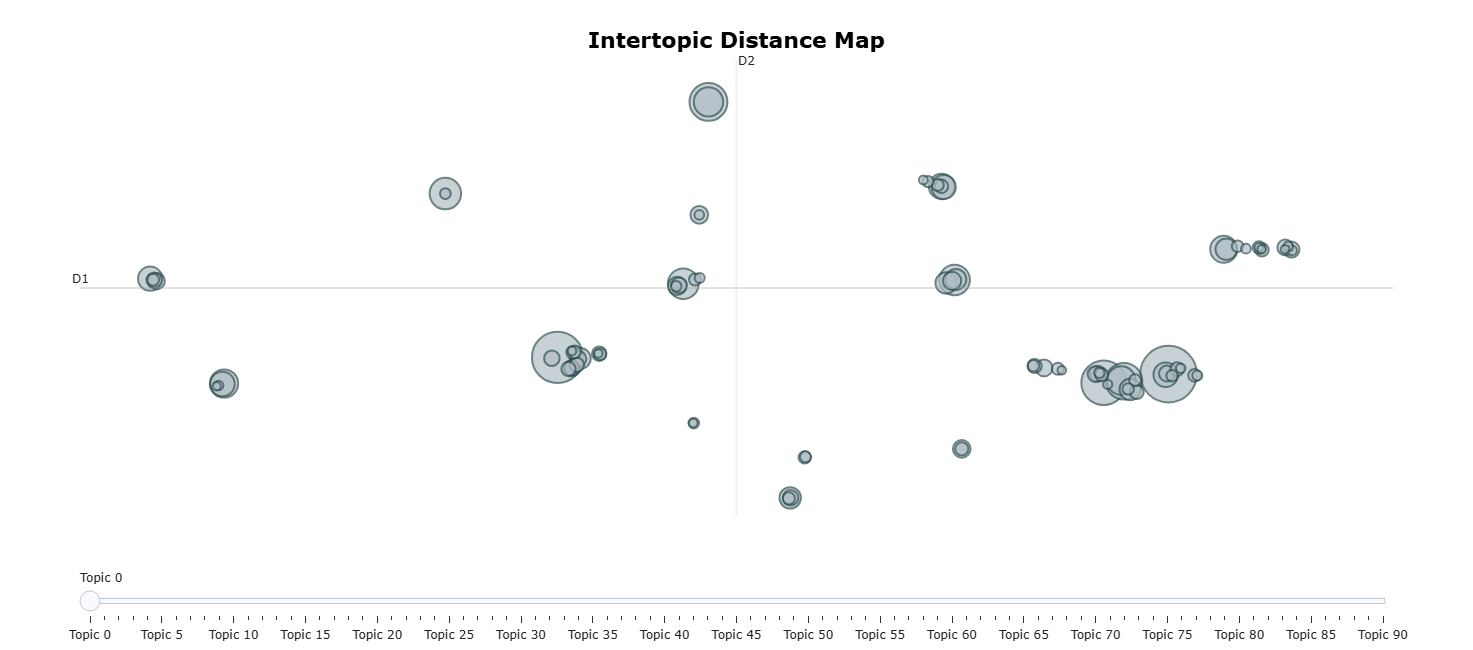

In [67]:
topic_model.visualize_topics()

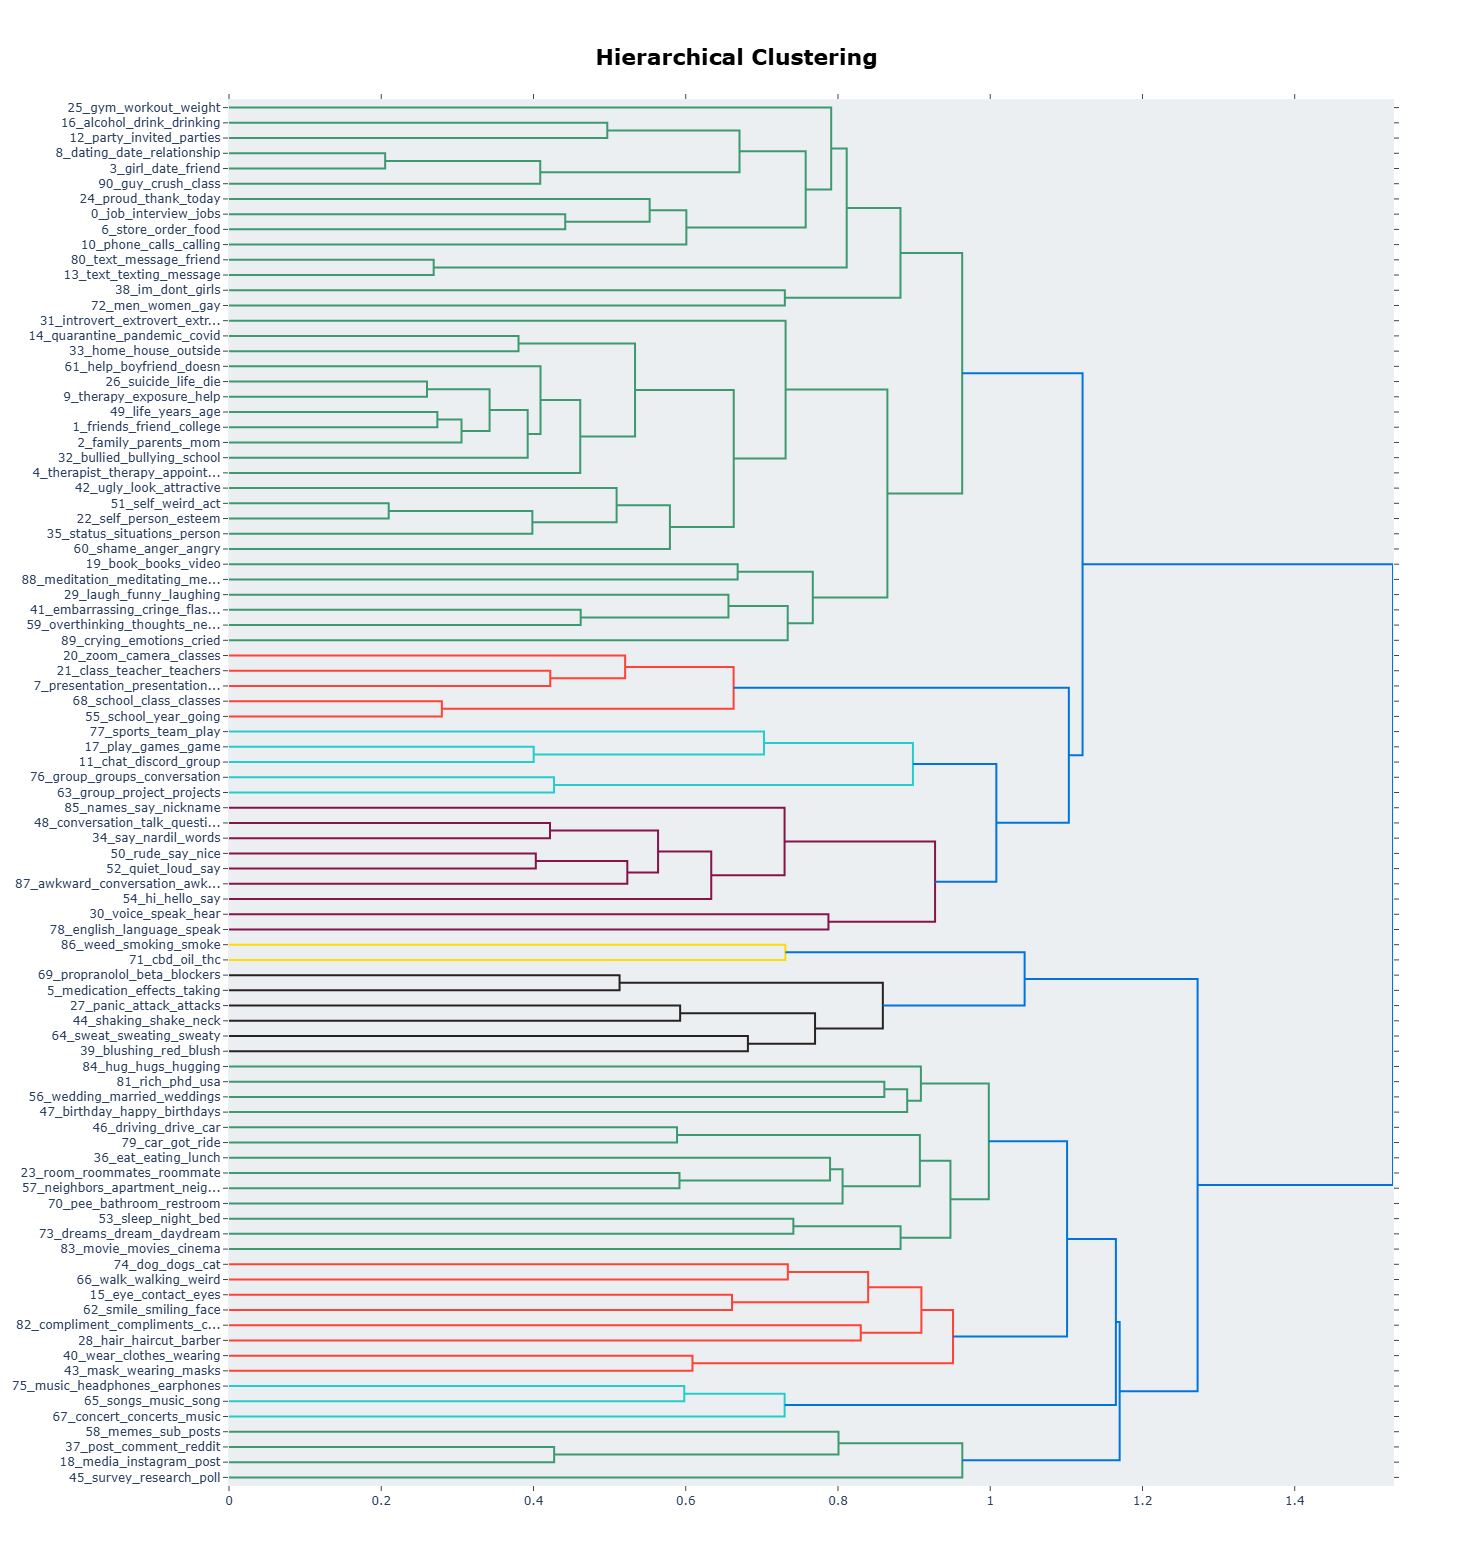

In [68]:
topic_model.visualize_hierarchy()

In [70]:
topic_info = topic_model.get_document_info(docs)

# Filter documents for a specific topic, for example, Topic 1
for i in range(topic_model.get_topic_info().shape[0] - 2):
    topic_docs = topic_info[topic_info['Topic'] == i]
    print(f'Topic {i}({len(topic_docs)}, ): {topic_docs.iloc[0]['Representation']}')

Topic 0(1328): ['job', 'interview', 'jobs', 'work', 'working', 'interviews', 'got', 'good', 'retail', 'customers']
Topic 1(1087): ['friends', 'friend', 'college', 'make', 'school', 'group', 'hang', 'new', 'want', 'lonely']
Topic 2(829): ['family', 'parents', 'mom', 'dad', 'sister', 'mother', 'tell', 'talk', 'want', 'help']
Topic 3(596): ['girl', 'date', 'friend', 'ask', 'said', 'asked', 'crush', 'didn', 'talk', 'good']
Topic 4(554): ['therapist', 'therapy', 'appointment', 'doctor', 'help', 'session', 'therapists', 'cbt', 'psychiatrist', 'sessions']
Topic 5(412): ['medication', 'effects', 'taking', 'meds', 'zoloft', 'dose', 'prescribed', 'doctor', 'depression', 'ssri']
Topic 6(390): ['store', 'order', 'food', 'shopping', 'ordering', 'buy', 'cashier', 'grocery', 'stores', 'shop']
Topic 7(388): ['presentation', 'presentations', 'class', 'speaking', 'speech', 'present', 'presenting', 'public', 'teacher', 'nervous']
Topic 8(357): ['dating', 'date', 'relationship', 'women', 'tinder', 'girls'

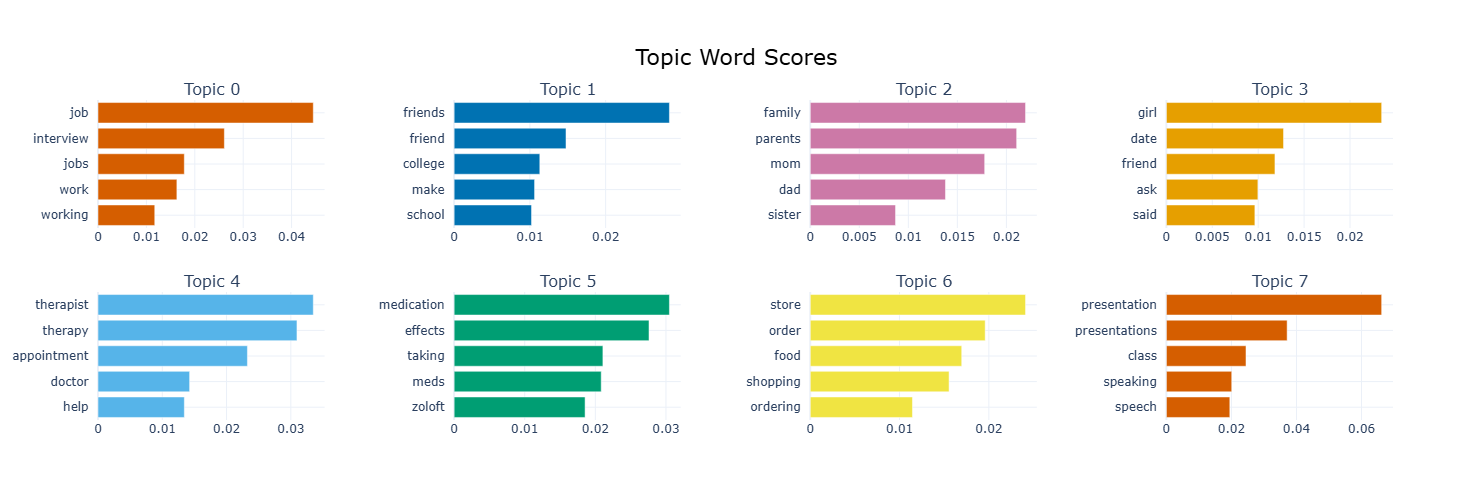

In [81]:
topic_model.visualize_barchart()

In [71]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine')
hdbscan_model = HDBSCAN(min_cluster_size=27, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
ctfidf_model = ClassTfidfTransformer()

In [72]:
from sklearn.cluster import KMeans
cluster_model = KMeans(n_clusters=13, random_state=42)
kmeans_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=cluster_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

In [73]:
topicsk, probsk = kmeans_model.fit_transform(docs)

In [74]:
kmeans_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,3427,0_way_things_person_want,"[way, things, person, want, say, talk, make, s...",[People commenting negative things when I try ...
1,1,3281,1_life_help_things_going,"[life, help, things, going, want, better, work...",[Does anyone else feel like they've wasted the...
2,2,3035,2_friends_school_want_life,"[friends, school, want, life, make, talk, frie...",[I feel empty I apologize for the long wall of...
3,3,2578,3_girl_friends_friend_want,"[girl, friends, friend, want, talk, say, girls...","[How many of you are able to date, and hold me..."
4,4,2531,4_say_talk_conversation_talking,"[say, talk, conversation, talking, person, awk...",[Can't stop thinking about what to say when I'...
5,5,2022,5_class_school_teacher_presentation,"[class, school, teacher, presentation, going, ...",[Do Teachers ever Shame or Embarrass you? I do...
6,6,1860,6_job_work_interview_phone,"[job, work, interview, phone, jobs, good, got,...",[My Terrible Experience With Working I started...
7,7,1859,7_post_online_want_media,"[post, online, want, media, reddit, chat, frie...","[I never post on Reddit, I read every single c..."
8,8,1429,8_therapy_medication_help_therapist,"[therapy, medication, help, therapist, doctor,...",[Went to the doctor today to treat my social a...
9,9,1384,9_look_eye_contact_looking,"[look, eye, contact, looking, face, wear, gym,...",[Suck at eye contact? Idk about you but eye co...


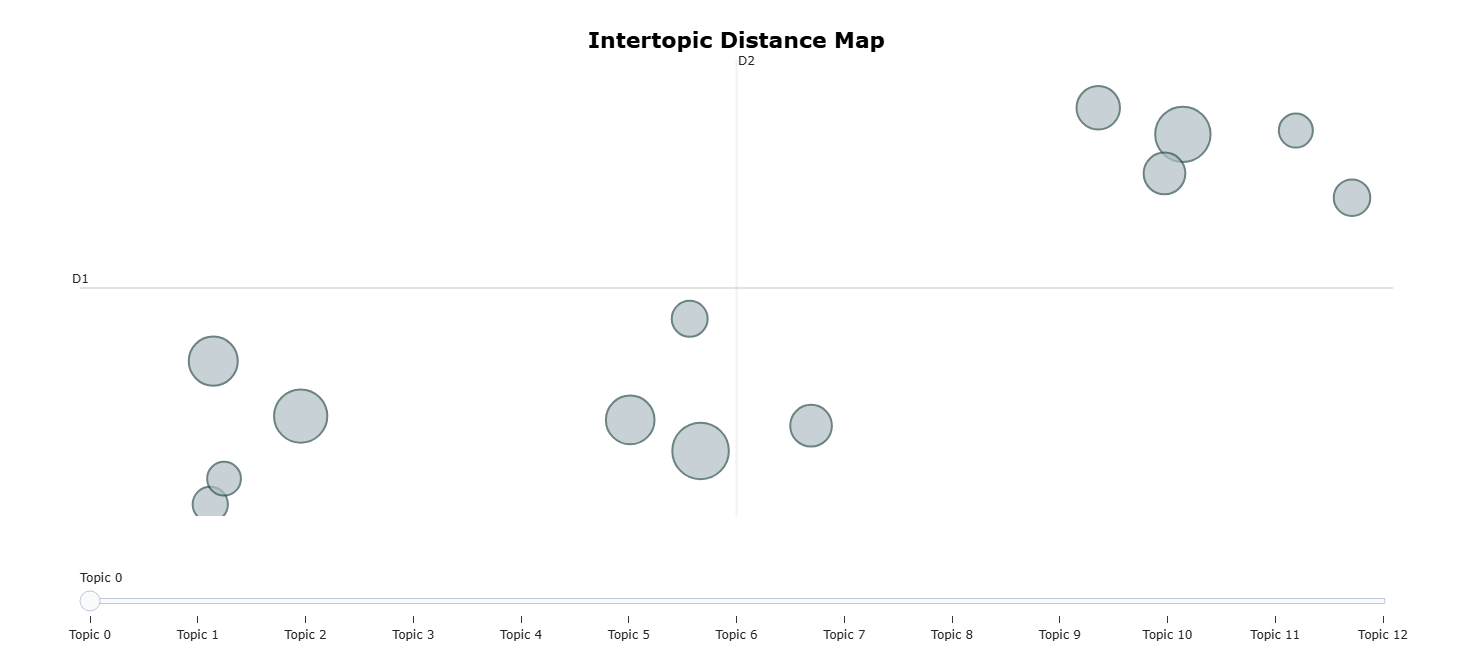

In [75]:
kmeans_model.visualize_topics()

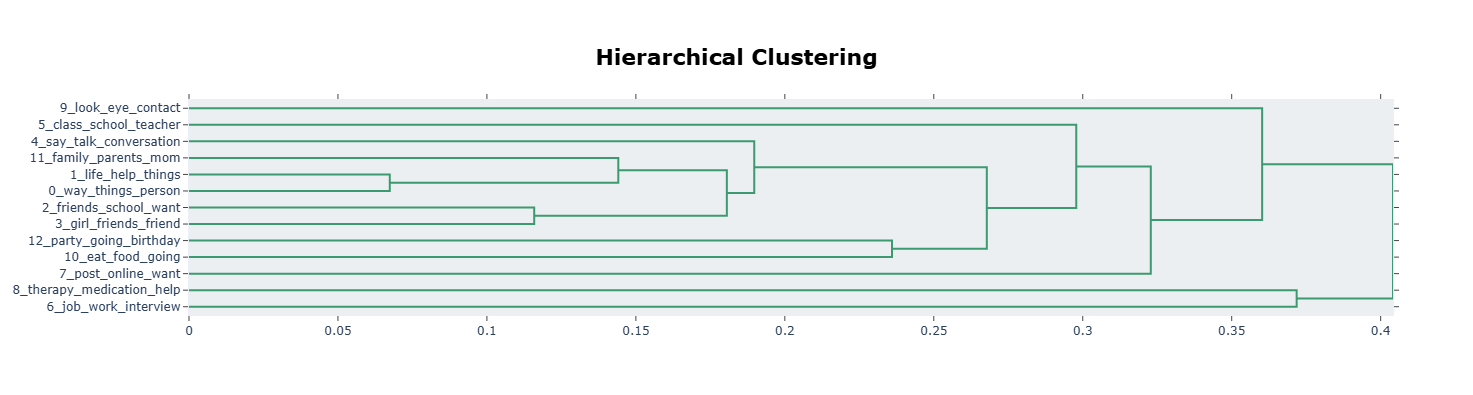

In [77]:
kmeans_model.visualize_hierarchy()

In [99]:
# Filter documents for a specific topic, for example, Topic 1
k_info = kmeans_model.get_document_info(docs)
for i in range(kmeans_model.get_topic_info().shape[0]):
    k_docs = k_info[k_info['Topic'] == i]
    print(f'Topic {i} ({round(((len(k_docs)/len(docs)) * 100),2)}%): {k_docs.iloc[0]['Representation']}')

Topic 0 (12.6%): ['way', 'things', 'person', 'want', 'say', 'talk', 'make', 'self', 'life', 'friends']
Topic 1 (12.06%): ['life', 'help', 'things', 'going', 'want', 'better', 'work', 'make', 'way', 'day']
Topic 2 (11.16%): ['friends', 'school', 'want', 'life', 'make', 'talk', 'friend', 'things', 'try', 'college']
Topic 3 (9.48%): ['girl', 'friends', 'friend', 'want', 'talk', 'say', 'girls', 'good', 'person', 'make']
Topic 4 (9.31%): ['say', 'talk', 'conversation', 'talking', 'person', 'awkward', 'try', 'things', 'make', 'way']
Topic 5 (7.43%): ['class', 'school', 'teacher', 'presentation', 'going', 'good', 'classes', 'group', 'did', 'say']
Topic 6 (6.84%): ['job', 'work', 'interview', 'phone', 'jobs', 'good', 'got', 'working', 'day', 'make']
Topic 7 (6.84%): ['post', 'online', 'want', 'media', 'reddit', 'chat', 'friends', 'play', 'make', 'talk']
Topic 8 (5.25%): ['therapy', 'medication', 'help', 'therapist', 'doctor', 'effects', 'taking', 'meds', 'appointment', 'work']
Topic 9 (5.09%):

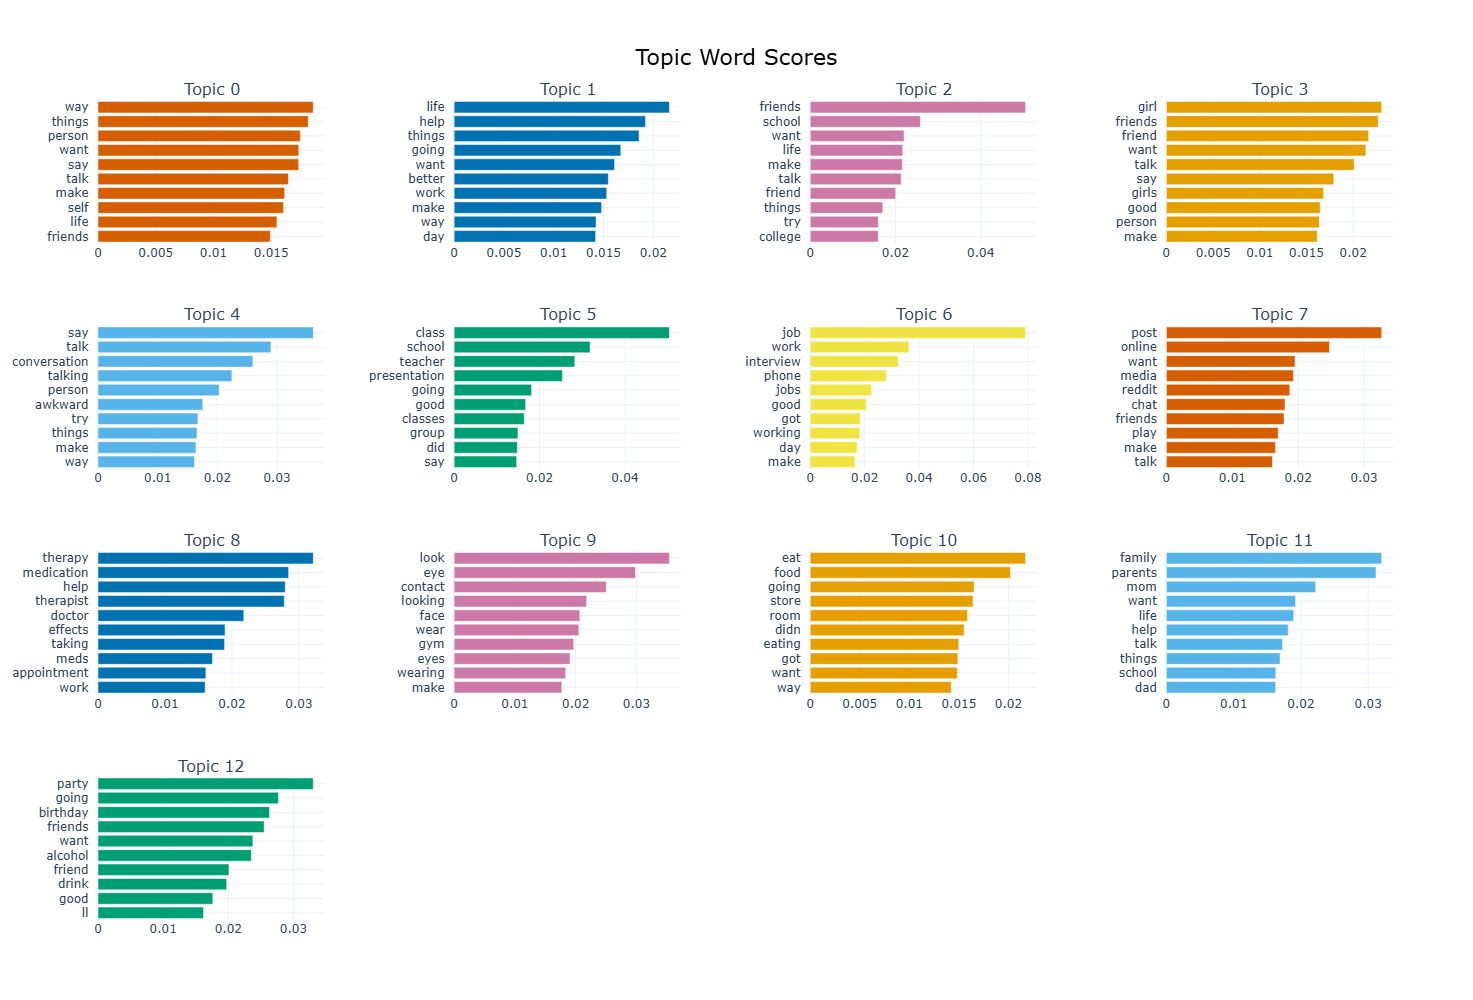

In [89]:
kmeans_model.visualize_barchart(top_n_topics = 13, n_words = 10)

In [80]:
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
topic_model.save("./Saved/Umap", serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)
kmeans_model.save("./Saved/Kmeans", serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)
